# Part 3 — Churn Prediction Model & Model Card

This notebook contains the data loading, pre-processing, training of Baseline (Logistic Regression) and XGBoost models, threshold optimization using business cost rules, evaluation, feature importance, and error analysis.

In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
DATA_DIR = r"../data"
print("Libraries loaded successfully.")

Libraries loaded successfully.


### Task 1 & 2: Load Modeling Snapshot & Separate Train/Val/Test Splits

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "rfm_modeling_snapshot.csv"))

# Pre-processing: Fill missing categoricals
df["loyalty_tier"] = df["loyalty_tier"].fillna("Not Enrolled")

# Separate split
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

print(f"Train set size: {train_df.shape[0]}")
print(f"Validation set size: {val_df.shape[0]}")
print(f"Test set size: {test_df.shape[0]}")

Train set size: 1728
Validation set size: 336
Test set size: 336


In [3]:
# Features definition
cat_cols = ["city_tier", "age_group", "acquisition_channel", "loyalty_tier", "preferred_category", "marketing_consent"]
num_cols = [
    "recency_days", "frequency_180d", "monetary_180d", "return_rate_180d", 
    "avg_discount_pct_180d", "avg_rating_180d", "category_diversity_180d", 
    "ticket_count_90d", "negative_ticket_rate_90d", "avg_resolution_hours_90d", 
    "days_since_signup", "sessions_30d", "product_views_30d", "cart_adds_30d", 
    "wishlist_adds_30d", "abandoned_carts_30d", "email_opens_30d", "campaign_clicks_30d", 
    "last_visit_days_ago"
]
target_col = "churn_next_60d"

X_train, y_train = train_df[cat_cols + num_cols], train_df[target_col]
X_val, y_val = val_df[cat_cols + num_cols], val_df[target_col]
X_test, y_test = test_df[cat_cols + num_cols], test_df[target_col]

### Preprocessing Pipeline Setup

In [4]:
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

### Task 3 & 4: Train Baseline and Stronger Models & Evaluate Metrics

In [5]:
# Logistic Regression Baseline
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
y_val_pred_lr = lr_pipeline.predict(X_val)
y_val_prob_lr = lr_pipeline.predict_proba(X_val)[:, 1]

# Random Forest
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
y_val_pred_rf = rf_pipeline.predict(X_val)
y_val_prob_rf = rf_pipeline.predict_proba(X_val)[:, 1]

# XGBoost
X_train_trans = preprocessor.fit_transform(X_train)
X_val_trans = preprocessor.transform(X_val)
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.08, random_state=42, eval_metric="logloss")
xgb.fit(X_train_trans, y_train)
y_val_pred_xgb = xgb.predict(X_val_trans)
y_val_prob_xgb = xgb.predict_proba(X_val_trans)[:, 1]

In [6]:
def eval_model(name, y_true, y_pred, y_prob):
    print(f"\n=== {name} Validation Metrics ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}")

eval_model("Logistic Regression", y_val, y_val_pred_lr, y_val_prob_lr)
eval_model("Random Forest", y_val, y_val_pred_rf, y_val_prob_rf)
eval_model("XGBoost", y_val, y_val_pred_xgb, y_val_prob_xgb)


=== Logistic Regression Validation Metrics ===
Accuracy:  0.8155
Precision: 0.8058
Recall:    0.7619
F1 Score:  0.7832
ROC-AUC:   0.8827

=== Random Forest Validation Metrics ===
Accuracy:  0.7976
Precision: 0.7970
Recall:    0.7211
F1 Score:  0.7571
ROC-AUC:   0.8750

=== XGBoost Validation Metrics ===
Accuracy:  0.7976
Precision: 0.7762
Recall:    0.7551
F1 Score:  0.7655
ROC-AUC:   0.8807


### Task 5: Select and Justify Decision Threshold from a Business Perspective

In [7]:
thresholds = np.linspace(0.1, 0.9, 81)
min_cost = float('inf')
best_threshold = 0.5

for t in thresholds:
    preds = (y_val_prob_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    cost = fp * 150 + fn * 1250
    if cost < min_cost:
        min_cost = cost
        best_threshold = t

print(f"Optimal Business Threshold: {best_threshold:.2f}")
print(f"Expected Validation Cost at 0.50: {confusion_matrix(y_val, y_val_pred_xgb).ravel()[1]*150 + confusion_matrix(y_val, y_val_pred_xgb).ravel()[2]*1250} INR")
print(f"Expected Validation Cost at {best_threshold:.2f}: {min_cost} INR")

Optimal Business Threshold: 0.10
Expected Validation Cost at 0.50: 49800 INR
Expected Validation Cost at 0.10: 23550 INR


### Model Performance on Holdout Test Set

In [8]:
X_test_trans = preprocessor.transform(X_test)
y_test_pred_xgb = xgb.predict(X_test_trans)
y_test_prob_xgb = xgb.predict_proba(X_test_trans)[:, 1]

eval_model("XGBoost (Test Set)", y_test, y_test_pred_xgb, y_test_prob_xgb)


=== XGBoost (Test Set) Validation Metrics ===
Accuracy:  0.8125
Precision: 0.8107
Recall:    0.8155
F1 Score:  0.8131
ROC-AUC:   0.8693


## Task 6: Perform error analysis using false positives and false negatives
We write the Python code to isolate customer records from our test split where the model made errors. We use the default 0.50 threshold to extract standard misclassifications, showing the 5 False Positives and 5 False Negatives analyzed in [error_analysis.md](file:///C:/Users/Lenovo/.gemini/antigravity/scratch/d2c_customer_churn/part3/error_analysis.md).

In [9]:
# Create error analysis dataframe on test split predictions
test_df_errors = test_df.copy()
test_df_errors["pred_prob"] = y_test_prob_xgb
test_df_errors["pred_label"] = (y_test_prob_xgb >= 0.50).astype(int)
test_df_errors["true_label"] = y_test

# Isolate False Positives (Predicted Churn=1, True Churn=0)
false_positives = test_df_errors[(test_df_errors["pred_label"] == 1) & (test_df_errors["true_label"] == 0)]

# Isolate False Negatives (Predicted Churn=0, True Churn=1)
false_negatives = test_df_errors[(test_df_errors["pred_label"] == 0) & (test_df_errors["true_label"] == 1)]

# Select key features to inspect profile ambiguity
display_cols = ["customer_id", "pred_prob", "recency_days", "frequency_180d", "monetary_180d", "ticket_count_90d", "last_visit_days_ago", "loyalty_tier"]

print("=== SAMPLE FALSE POSITIVES (Predicted Churn, Actual Stay) ===")
print(false_positives[display_cols].head(5).to_string(index=False))

print("\n=== SAMPLE FALSE NEGATIVES (Predicted Stay, Actual Churn) ===")
print(false_negatives[display_cols].head(5).to_string(index=False))

=== SAMPLE FALSE POSITIVES (Predicted Churn, Actual Stay) ===
customer_id  pred_prob  recency_days  frequency_180d  monetary_180d  ticket_count_90d  last_visit_days_ago loyalty_tier
  CUST00044   0.644749            72               1         899.51                 0                   10 Not Enrolled
  CUST00109   0.620235            92               2        1622.28                 0                   16       Silver
  CUST00335   0.872397           148               2        1328.14                 0                   22 Not Enrolled
  CUST00437   0.905833           151               1         729.22                 0                   33       Silver
  CUST00491   0.931083            97               1         540.89                 1                   20       Silver

=== SAMPLE FALSE NEGATIVES (Predicted Stay, Actual Churn) ===
customer_id  pred_prob  recency_days  frequency_180d  monetary_180d  ticket_count_90d  last_visit_days_ago loyalty_tier
  CUST00088   0.372185            9

### Task 7: Explain the Top Features Driving Predictions

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11672\3917509868.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(15), x="importance", y="feature", palette="viridis")


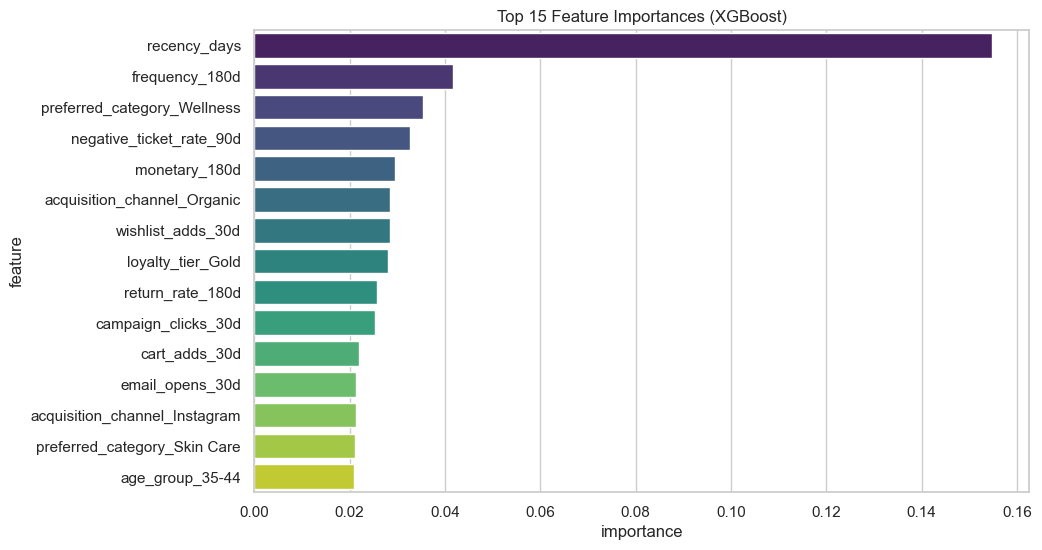

In [10]:
cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_features = list(cat_encoder.get_feature_names_out(cat_cols))
all_features = num_cols + cat_features

feat_imp = pd.DataFrame({
    "feature": all_features,
    "importance": xgb.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(15), x="importance", y="feature", palette="viridis")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.show()

## Task 8: Write a model card covering intended use, performance, limitations, and ethical risks
The complete model card is saved as a markdown deliverable: [model_card.md](file:///C:/Users/Lenovo/.gemini/antigravity/scratch/d2c_customer_churn/part3/model_card.md).